In [120]:
import pandas as pd

In [121]:
import pandas as pd

In [122]:
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")

## Loading the Dataset

The Online Retail dataset was loaded into a Pandas DataFrame using the `read_csv()` function.

The `encoding="latin1"` parameter was used because the dataset contains special characters that could not be read using the default UTF-8 encoding.

In [123]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


## Dataset Information

The `df.info()` function was used to examine the structure of the dataset.

From the output, we observed that:

- The dataset initially contained **541,909 rows** and **8 columns**.
- The dataset includes both numerical and categorical variables.
- The `Description` and `CustomerID` columns contained missing values.
- The `InvoiceDate` column was initially stored as a string and was later converted to a datetime format during the data cleaning process.

This step helped identify data quality issues that needed to be addressed before analysis.

In [125]:
df.duplicated().sum()

np.int64(5268)

## Checking for Duplicate Records

The `df.duplicated().sum()` function was used to identify duplicate rows in the dataset.

The output showed that the dataset contained **5,268 duplicate records**. Duplicate records can lead to inaccurate analysis by counting the same transaction more than once. Therefore, these duplicate rows needed to be removed before proceeding with the analysis.

In [126]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Checking for Missing Values

The `df.isnull().sum()` function was used to identify missing values in each column of the dataset.

The results showed that:

- **Description** contained **1,454** missing values.
- **CustomerID** contained **135,080** missing values.
- All other columns had **no missing values**.

Identifying missing values is an important step in data cleaning because missing data can affect the accuracy and reliability of the analysis. Appropriate cleaning methods were applied in the next step to handle these missing values.

In [127]:
df = df.drop_duplicates()

## Removing Duplicate Records

The duplicate records were removed using the `drop_duplicates()` function to improve the quality and accuracy of the dataset.

This ensures that each transaction is counted only once during the analysis.

In [128]:
df.duplicated().sum()

np.int64(0)

## Verification of Duplicate Removal

The dataset was checked again for duplicate records after cleaning.

The output showed **0 duplicate rows**, confirming that all duplicate records were successfully removed.

In [129]:
df = df.dropna(subset=["CustomerID"])

## Handling Missing Values

Rows with missing **CustomerID** values were removed using the `dropna()` function.

This approach was chosen because CustomerID is important for identifying individual customers and performing customer-based analysis. After removing these rows, the dataset no longer contained missing values in the remaining columns.

In [130]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Verification of Missing Value Removal

The dataset was checked again for missing values after cleaning.

The output showed **0 missing values** in all columns, confirming that the missing data had been successfully handled and the dataset was ready for further analysis.

In [131]:
df = df[df["Quantity"] > 0]

## Validating the Quantity Column

The `Quantity` column was checked for invalid values.

Rows with a quantity less than or equal to zero were removed because they represent returned items, cancelled orders, or invalid transactions. Keeping only positive quantities ensures that the dataset contains valid sales transactions for accurate analysis.

In [132]:
df = df[df["UnitPrice"] > 0]

## Validating the UnitPrice Column

The `UnitPrice` column was checked for invalid values.

Rows with a unit price less than or equal to zero were removed because they do not represent valid sales transactions. Removing these records improves the quality of the dataset and ensures that the analysis is based on genuine sales data.

In [133]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,15287.843865
std,180.492832,22.241836,1713.539549
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13955.000000
50%,6.000000,1.950000,15150.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,8142.750000,18287.000000


## Summary Statistics

The `df.describe()` function was used to generate summary statistics for the numerical columns in the dataset.

The results show that:

- The cleaned dataset contains **392,692 valid transactions**.
- The minimum quantity is **1**, confirming that all invalid or negative quantities were successfully removed.
- The minimum unit price is **0.001**, confirming that all zero and negative prices were removed.
- The summary statistics provide an overview of the distribution of numerical variables, including the mean, standard deviation, minimum, maximum, and quartiles.

These statistics confirm that the dataset has been successfully cleaned and is ready for exploratory data analysis.

In [134]:
df.shape

(392692, 8)

## Dataset Size

The `df.shape` function was used to determine the dimensions of the cleaned dataset.

The output showed that the dataset contains **392,692 rows** and **8 columns**.

This means that after removing duplicate records, handling missing values, and eliminating invalid transactions, the dataset consists of **392,692 valid observations** across **8 variables** that are ready for analysis.

## Dataset Size

The cleaned dataset contains **392,692 rows** and **8 columns**.

In [135]:
df .dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

## Numerical Features

The numerical features in the dataset are:

- Quantity
- UnitPrice
- CustomerID

## Categorical Features

The categorical features in the dataset are:

- InvoiceNo
- StockCode
- Description
- Country

InvoiceDate has been converted to a datetime format for time-based analysis.

## Possible Unique Identifier (Primary Key)

The dataset does not contain a single column that uniquely identifies every record.

- InvoiceNo is not unique because one invoice can contain multiple products.
- StockCode is not unique because the same product can appear in many invoices.
- CustomerID is not unique because one customer can make multiple purchases.

A combination of **InvoiceNo** and **StockCode** can be used to uniquely identify most transaction records.

## Dataset Description

The Online Retail dataset contains transaction records from an online retail store.

Each row represents a product purchased during a customer transaction. The dataset includes invoice numbers, product codes, product descriptions, quantities purchased, unit prices, customer IDs, purchase dates, and the customer's country.

The dataset can be used to analyze customer purchasing behavior, product sales, and business performance.

In [136]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [137]:
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [138]:
df.columns = df.columns.str.lower()

## Standardizing Column Names

The column names were standardized by converting all column names to lowercase.

Standardizing column names improves consistency throughout the dataset and makes it easier to reference columns in Python without worrying about differences in capitalization. This also helps reduce the likelihood of errors when writing code.

In [139]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='str')

## Standardization

The following standardization steps were performed:

- Converted the `InvoiceDate` column from string to datetime format.
- Standardized all column names by converting them to lowercase for consistency.

## Standardization

The following standardization steps were performed to improve consistency across the dataset:

- Converted the **InvoiceDate** column from string format to **datetime**.
- Standardized all column names by converting them to **lowercase**.

---

## Cleaning Summary

| Issue Found | Action Taken |
|-------------|--------------|
| Missing Description values | Removed rows with missing `description` values. |
| Missing CustomerID values | Removed rows with missing `customerid` values. |
| Duplicate Records | Removed **5,268** duplicate rows using `drop_duplicates()`. |
| Invalid Quantity values | Removed rows where `quantity <= 0`. |
| Invalid Unit Price values | Removed rows where `unitprice <= 0`. |
| Date Format | Converted `InvoiceDate` to datetime format. |
| Column Names | Converted all column names to lowercase for consistency. |

### Conclusion

The dataset is now clean, standardized, and ready for exploratory data analysis (EDA). Missing values, duplicate records, invalid entries, and formatting inconsistencies have been addressed to improve data quality and reliability.

# Task 3: Exploratory Data Analysis (EDA)

This section explores the cleaned dataset to identify patterns, trends, and insights that can support business decision-making.

In [140]:
df.describe()

,quantity,invoicedate,unitprice,customerid
count,392692.000000,392692,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.492832,NaN,22.241836,1713.539549


## Summary Statistics

The `df.describe()` function was used to generate summary statistics for the numerical and datetime columns in the cleaned dataset.

Key observations include:

- The cleaned dataset contains **392,692 valid transactions**.
- The average quantity purchased per transaction is approximately **13 items**.
- The average unit price is approximately **3.13**.
- The transaction dates range from **1 December 2010** to **9 December 2011**.
- The minimum quantity is **1**, confirming that invalid quantities were successfully removed.
- The minimum unit price is **0.001**, confirming that zero and negative prices were removed.

These statistics provide an overview of the dataset and confirm that it is ready for exploratory analysis.

In [141]:
top_products = df.groupby("description")["quantity"].sum().sort_values(ascending=False).head(10)

top_products

description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: quantity, dtype: int64

## Top-Selling Products

The total quantity sold for each product was calculated by grouping the dataset by product description and summing the quantities sold.

The results show that **PAPER CRAFT, LITTLE BIRDIE** was the best-selling product, with **80,995 units** sold. Other highly purchased products include **MEDIUM CERAMIC TOP STORAGE JAR**, **WORLD WAR 2 GLIDERS ASSTD DESIGNS**, and **JUMBO BAG RED RETROSPOT**.

This analysis helps identify the products with the highest sales volume, which can support inventory management and marketing decisions.

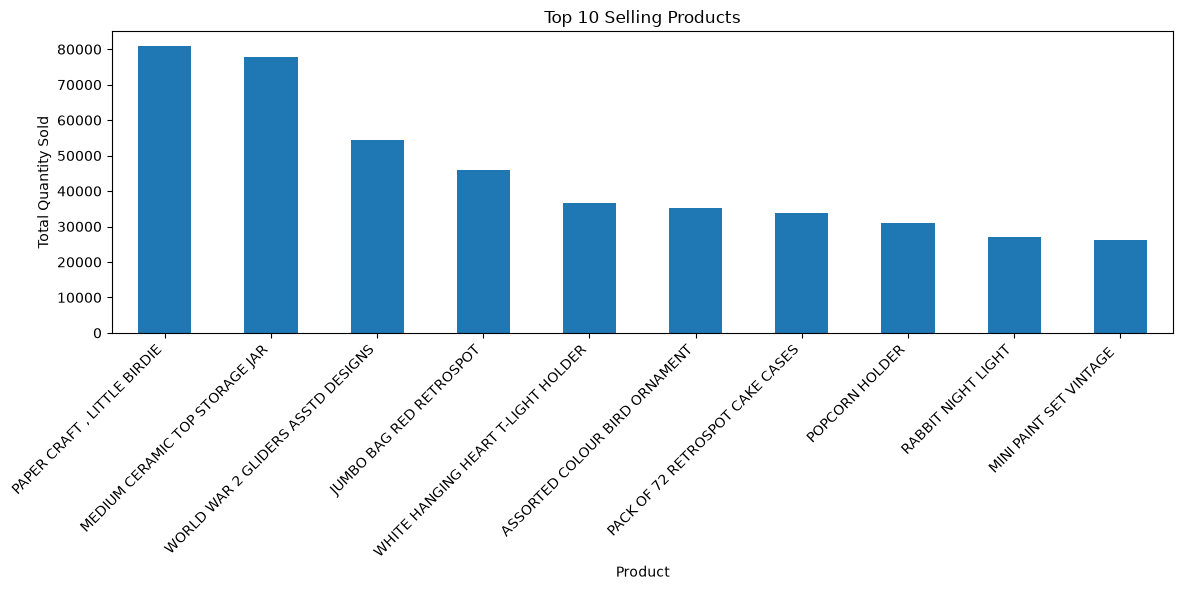

In [142]:
import matplotlib.pyplot as plt

top_products.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Findings

The bar chart shows that **PAPER CRAFT, LITTLE BIRDIE** is the highest-selling product, with over 80,000 units sold.

Other products such as **MEDIUM CERAMIC TOP STORAGE JAR** and **WORLD WAR 2 GLIDERS ASSTD DESIGNS** also recorded high sales volumes.

These findings help identify the products that are most popular with customers and can support inventory planning, stock management, and marketing strategies.

## Highest Revenue-Generating Countries

This analysis calculates the total revenue generated by each country to identify the markets that contribute the most to the company's sales.

In [143]:
df["revenue"] = df["quantity"] * df["unitprice"]

country_revenue = df.groupby("country")["revenue"].sum().sort_values(ascending=False)

country_revenue.head(10)

country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: revenue, dtype: float64

### Findings

The analysis shows that the **United Kingdom** generated the highest total revenue, contributing significantly more than any other country.

Other major revenue-generating countries include the **Netherlands**, **EIRE**, **Germany**, and **France**.

This indicates that the United Kingdom is the company's primary market, while several European countries also make substantial contributions to total sales.

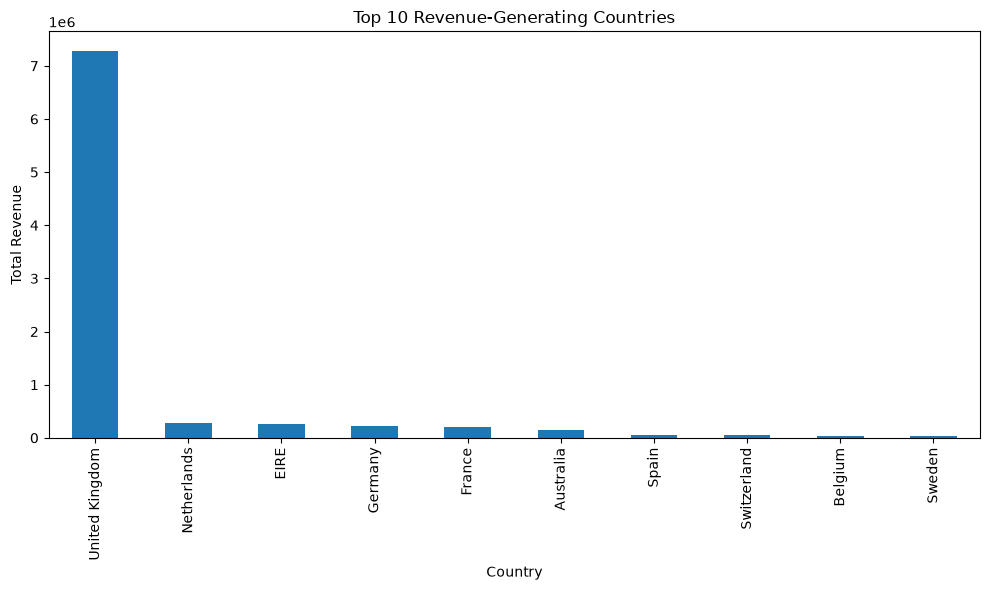

In [144]:
country_revenue.head(10).plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Revenue-Generating Countries")
plt.xlabel("Country")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

### Findings

The bar chart clearly shows that the **United Kingdom** is the company's largest source of revenue.

Although countries such as the Netherlands, EIRE, Germany, and France contribute considerably, their revenues are much lower than that of the United Kingdom. This suggests that the business relies heavily on the UK market while maintaining a strong presence across several European countries.

## Monthly Sales Trends

This analysis examines how sales changed over time by calculating the total revenue generated each month. The results help identify seasonal patterns and business performance trends.

In [145]:
df["month"] = df["invoicedate"].dt.to_period("M")

monthly_sales = df.groupby("month")["revenue"].sum()

monthly_sales

month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: revenue, dtype: float64

### Findings

The monthly sales analysis shows that revenue fluctuated throughout the year.

Sales increased significantly during September, October, and November 2011, with **November 2011** recording the highest revenue. Although December 2011 shows lower revenue, this is likely because the dataset only contains transactions up to 9 December 2011.

Understanding monthly sales trends helps businesses identify seasonal demand and improve sales forecasting.

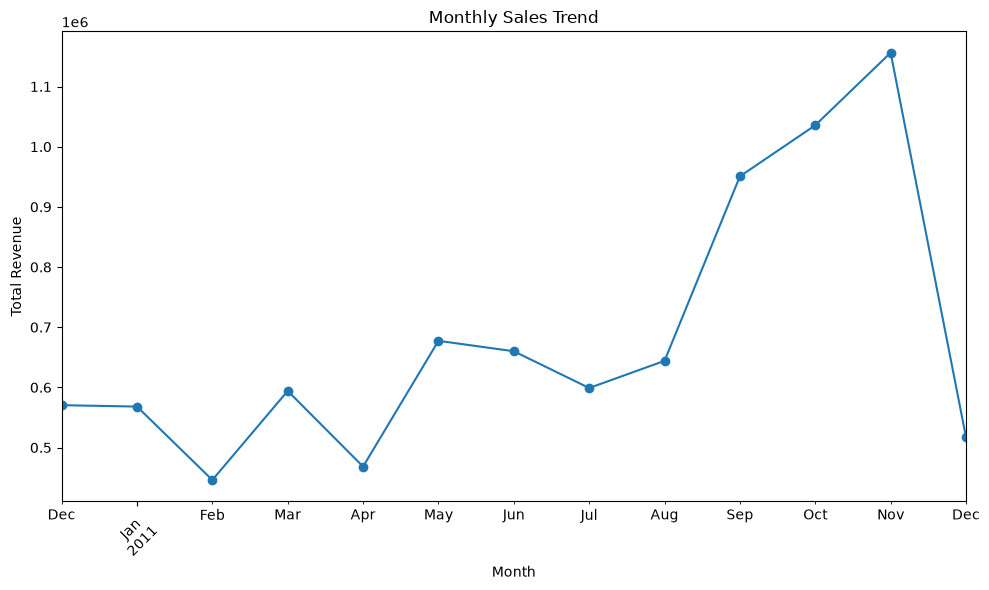

In [146]:
monthly_sales.plot(kind="line", figsize=(10,6), marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Findings

The line chart clearly shows an upward sales trend during the second half of 2011.

Revenue peaked in **November 2011**, indicating a period of exceptionally strong sales. The lower revenue recorded in December is expected because the dataset only contains part of the month's transactions.

The visualization makes it easier to identify sales patterns and seasonal business performance.

## Customer Purchasing Behavior

This analysis identifies the customers who made the highest number of purchases by calculating the total quantity of items purchased by each customer.

The results provide insight into customer buying behavior and help identify the most active customers.

In [147]:
customer_purchases = df.groupby("customerid")["quantity"].sum().sort_values(ascending=False)

customer_purchases.head(10)

customerid
14646.0    196915
16446.0     80997
14911.0     80240
12415.0     77374
12346.0     74215
17450.0     69973
17511.0     64549
18102.0     64124
13694.0     63312
14298.0     58343
Name: quantity, dtype: int64

### Findings

The analysis shows that **Customer 14646** purchased the highest quantity of products, followed by customers **16446**, **14911**, and **12415**.

These customers represent the company's most active buyers and contribute significantly to total sales volume. Identifying high-value customers can help the business develop customer loyalty programs, personalized marketing campaigns, and targeted promotions.

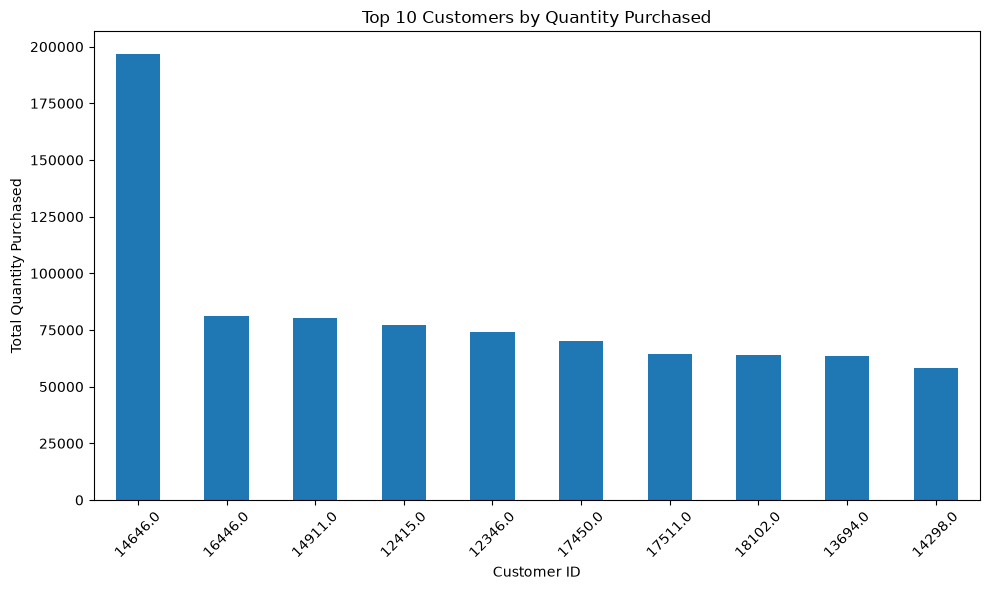

In [148]:
customer_purchases.head(10).plot(kind="bar", figsize=(10,6))

plt.title("Top 10 Customers by Quantity Purchased")
plt.xlabel("Customer ID")
plt.ylabel("Total Quantity Purchased")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Findings

The bar chart shows that **Customer 14646** purchased considerably more items than any other customer.

The remaining top customers also purchased large quantities, indicating that a relatively small group of customers contributes substantially to total sales. These customers may be valuable targets for retention strategies and reward programs.

## Distribution of Product Prices

This visualization shows how product prices are distributed across the dataset and helps identify the most common price ranges.

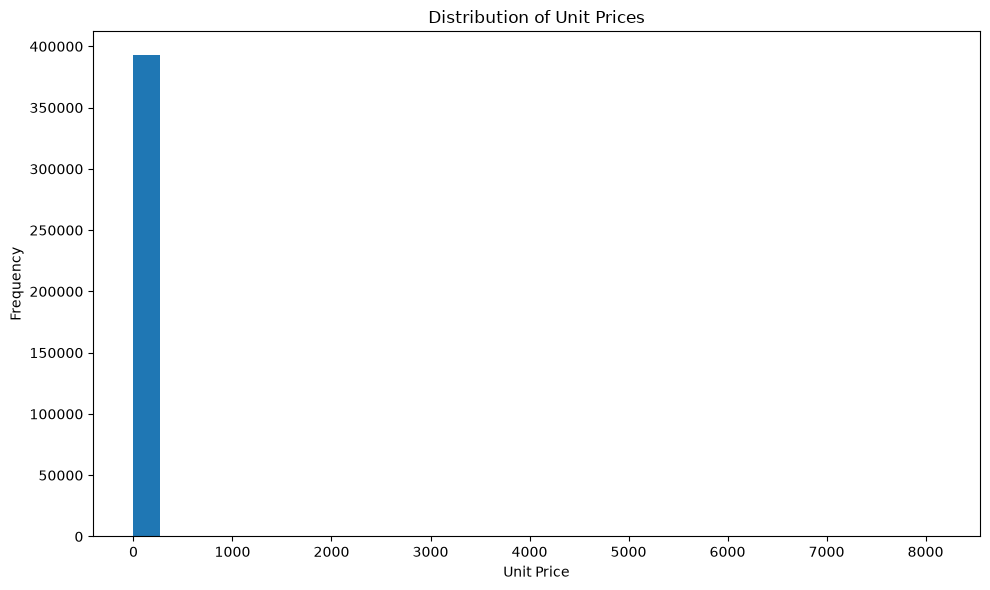

In [149]:
df["unitprice"].plot(kind="hist", bins=30, figsize=(10,6))

plt.title("Distribution of Unit Prices")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Findings

The histogram shows that most products have relatively low unit prices, while only a small number of products have very high prices.

This indicates that the dataset is right-skewed, meaning the majority of products are inexpensive, with a few premium-priced products creating the long tail of the distribution.

# Task 5: Key Insights

## Key Insights

### Insight 1: Best-Selling Products
The analysis showed that **PAPER CRAFT, LITTLE BIRDIE** was the best-selling product, followed by **MEDIUM CERAMIC TOP STORAGE JAR** and **WORLD WAR 2 GLIDERS ASSTD DESIGNS**. This indicates that these products were in high customer demand and contributed significantly to total sales volume.

**Reference:** Bar Chart – Top 10 Selling Products.

---

### Insight 2: Revenue by Country
The **United Kingdom** generated by far the highest revenue, contributing over **£7.2 million**, while countries such as the Netherlands, EIRE, Germany, and France generated substantially lower revenue. This suggests that the United Kingdom is the company's primary market.

**Reference:** Bar Chart – Highest Revenue by Country.

---

### Insight 3: Monthly Sales Trend
Monthly revenue generally increased throughout 2011, with sales reaching their highest levels in **October and November**. This pattern suggests increased customer purchasing during the holiday shopping season.

**Reference:** Line Chart – Monthly Sales Trend.

---

### Insight 4: Customer Purchasing Behavior
A small number of customers purchased significantly larger quantities than others. For example, Customer **14646** recorded the highest purchase quantity, indicating that a few high-value customers contribute a substantial portion of total sales.

**Reference:** Bar Chart – Top Customers by Quantity Purchased.

---

### Insight 5: Product Price Distribution
The histogram showed that most products were sold at relatively **low unit prices**, while only a small number of products had very high prices. This indicates that the retailer primarily sells affordable products with a few premium-priced items.

**Reference:** Histogram – Distribution of Unit Prices.

In [150]:
df.to_csv("OnlineRetail_Cleaned.csv", index=False)

## Exporting the Cleaned Dataset

The cleaned dataset was exported as **OnlineRetail_Cleaned.csv** for submission.